#**Algoritmos de optimización - Trabajo Práctico**<br>
Nombre y Apellidos: Kenny Pizarro Luzón  <br>
Url: https://github.com/Kenny-ec/03MAIR-Algoritmos_de_Optimizacion/tree/main/Trabajo_practico<br>
Google Colab: https://colab.research.google.com/drive/1Xf_u0JKKdWS75LEmHrzpE-ja_OAN-bia?usp=sharing <br>
Problema:
>1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de una jornada de La Liga<br>
>3. Configuración de Tribunales

Descripción del problema:








                                        

##**Organizar los horarios de partidos de La Liga**<br>
Desde la La Liga de fútbol profesional se pretende organizar los horarios de los partidos de liga de cada jornada. Se conocen algunos datos que nos deben llevar a diseñar un algoritmo que realice la asignación de los partidos a los horarios de forma que **maximice la audiencia**.

Los horarios disponibles se conocen a priori y son los siguientes:

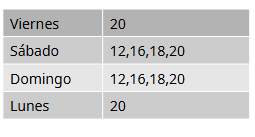

En primer lugar se clasifican los equipos en tres categorías según el numero de seguidores( que tiene relación directa con la audiencia). Hay 3 equipos en la categoría A, 11 equipos de categoría B y 6 equipos de categoría C.

Se conoce estadísticamente la audiencia que genera cada partido según los equipos
que se enfrentan y en horario de sábado a las 20h (el mejor en todos los casos)

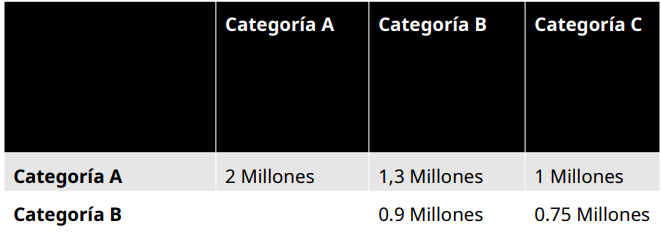

Si el horario del partido no se realiza a las 20 horas del sábado se sabe que se reduce según los coeficientes de la siguiente tabla:

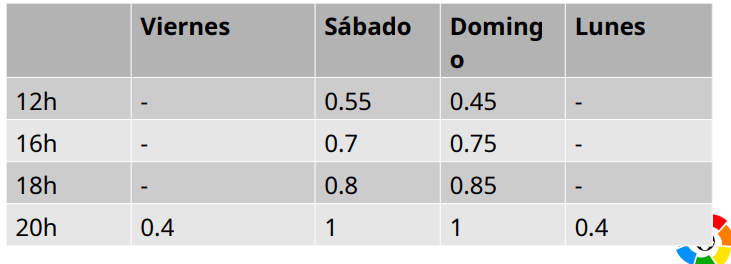

Debemos asignar obligatoriamente siempre un partido el viernes y un partido el lunes.
Es posible la coincidencia de horarios pero en este caso la audiencia de cada partido se verá afectada y se estima que se reduce en porcentaje según la siguiente tabla dependiendo del número de coincidencias:

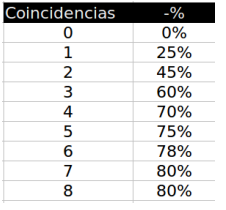

Los cálculos asociados a una jornada de ejemplo se realizan según se muestra en la siguiente tabla:

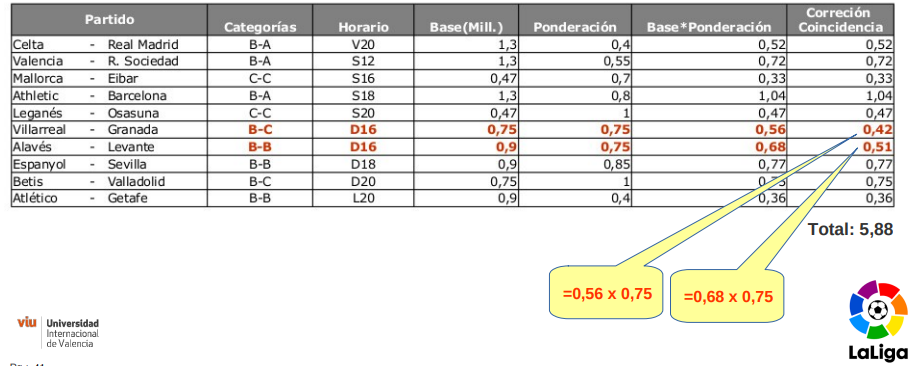

##**RESOLUCION** <br>

In [2]:
# LIBRERIAS A UTILIZAR
import numpy as np
import random
import matplotlib.pyplot as plt

In [3]:
# DEFINICIONES

#Horarios
horarios = ["V20", "S12", "S16", "S18", "S20", "D12", "D16", "D18", "D20", "L20"]

#Coeficientes
horarios_coef = [0.4, 0.55, 0.7, 0.8, 1.0, 0.45, 0.75, 0.85, 1.0, 0.4]

#Audiencia
audiencia_base = [
    [2.0, 1.5, 1.0],  # A-A, A-B, A-C
    [1.5, 0.9, 0.75], # B-A, B-B, B-C
    [1.0, 0.75, 0.47] # C-A, C-B, C-C
]

#Penalizaciones de las coincidencias
penalizaciones = [0.0, 0.25, 0.45, 0.60, 0.70, 0.75, 0.78, 0.80, 0.80]

#Patridos de la Jornada
partidos_jornada = [
    (1, 0), (1, 0), (2, 2), (1, 0), (2, 2),
    (1, 2), (1, 1), (1, 1), (1, 2), (1, 1)
]

In [4]:
def calcular_fitness(cromosoma):
    # Verificar si se cumple la restricción obligatoria: Viernes (0) y Lunes (9)
    if 0 not in cromosoma or 9 not in cromosoma:
        return 0.01

    audiencia_total = 0
    conteo_horarios = {i: cromosoma.count(i) for i in range(10)}


    # Realizamos una iteración por cada partido (i) y el horario asignado (slot_idx) en el cromosoma actual
    for i, slot_idx in enumerate(cromosoma):
        #Obtenemos la categoria de los dos equipos
        cat1, cat2 = partidos_jornada[i]

        # Obtenemos la audiencia
        base = audiencia_base[cat1][cat2]
        audiencia_parcial = base * horarios_coef[slot_idx]

        # Calculamos los partidos que coinciden en el mismo horario
        n_coincidencias = conteo_horarios[slot_idx] - 1

        # Aplicamos penalizaciones a los partidos que tienen el mismo horario
        if n_coincidencias > 0:
            idx_pen = min(n_coincidencias, len(penalizaciones)-1)
            audiencia_parcial *= (1 - penalizaciones[idx_pen])

        audiencia_total += audiencia_parcial
    return audiencia_total

In [5]:
tamanio_poblacion = 100 # Definimos al algorito el numero de soluciones candidatas para el ejercicio
generaciones = 200 # Definimos el número de evoluciones para llegar al máximo de la funcion objetivo

#Población inicial con 100 individuos aleatorios, los cuales cada uno contiene los 10 horarios para los 10 partidos
poblacion = [[random.randint(0, 9) for _ in range(10)] for _ in range(tamanio_poblacion)]

# Creamos una lista para almacenar el mejor valor de la audiencia de cada generación
historial_fitness = []

In [6]:
for gen in range(generaciones):
    # Ordenamos la población de mayor a menor en base a la audiencia
    poblacion = sorted(poblacion, key=lambda c: calcular_fitness(c), reverse=True)

    #Obtenemos la mejor audiencia en la generacion actual
    mejor_f = calcular_fitness(poblacion[0])
    historial_fitness.append(mejor_f)

    # Preservamos los 10 mejores individuos para la siguiente generacion
    nueva_gen = poblacion[:10]

    # El siguiente bloque crea una nueva generacion de soluciones que intenta superar la audiencia máxima
    while len(nueva_gen) < tamanio_poblacion:
        # Fase de Selección
        p1, p2 = random.sample(poblacion[:50], 2)

        # Fase de Cruce
        punto = random.randint(1, 8)
        hijo = p1[:punto] + p2[punto:]

        # Fase de Mutación
        if random.random() < 0.1:
            hijo[random.randint(0, 9)] = random.randint(0, 9)

        nueva_gen.append(hijo)

    poblacion = nueva_gen

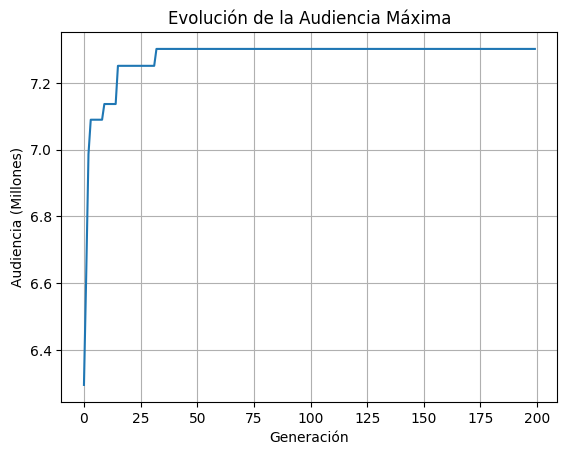

Mejor Audiencia Encontrada: 7.30 Millones


In [7]:
plt.plot(historial_fitness)
plt.title('Evolución de la Audiencia Máxima')
plt.xlabel('Generación')
plt.ylabel('Audiencia (Millones)')
plt.grid(True)
plt.show()

mejor_solucion = poblacion[0]
print(f"Mejor Audiencia Encontrada: {calcular_fitness(mejor_solucion):.2f} Millones")

##**Modelo**
**¿Como represento el espacio de soluciones?**<br>
El espacio de soluciones se lo representa mediante un cromosoma (individuo) el cual está formado por una lista de 10 números enteros, esta lista está compuesta por:

*   La posición de la lista, que representa cada uno de los 10 partidos
*   El valor de cada elemento de la lista, que representa el horario asignado al partido, por ejemplo: V20, S12, L20, etc.
<br>

**¿Cual es la función objetivo?**<br>
La función objetivo está denotada por la función calcular_fitness(cromosoma), el cual tiene como objetivo calcular la mejor audiencia de dicha generación en el bucle for.<br>

**¿Como implemento las restricciones?**<br>
En base a las restricciones dadas en la descripción del problema ,las restricciones se implementaron de la siguiente manera:

Se definieron las penalizaciones:<br>

In [8]:
penalizaciones = [0.0, 0.25, 0.45, 0.60, 0.70, 0.75, 0.78, 0.80, 0.80]

Luego, dentro de la función objetivo se calcularon las penalizaciones en caso de que hayan dos partidos que coincidan en el mismo horario, finalmente se calcula la audiencia restando puntos por la penalización aplicada

Ejemplo:

In [11]:
audiencia_p = 40
n_coincidencias = 2

if n_coincidencias > 0:
  idx_pen = min(n_coincidencias, len(penalizaciones)-1)
  audiencia_p *= (1 - penalizaciones[idx_pen])

##**Análisis**
**¿Que complejidad tiene el problema?**<br>
El problema es de Complejidad Exponencial $O(m^n)$, debido a que:

*   **n** es el número de partidos a asignar
*   **m** es le número de horarios para cada elemento

La clasificación del problema es NP-Hard debido a las restricciones y a la función de la audiencia, la cual no es lineal.<br>

Con respecto al espacio de soluciones, este representa todas las combinaciones posibles de los horarios que el algoritmo podría evaluar. Al analizar el problema, se puede realizar variaciones con repetición de partidos por lo que la magnitud del espacio total de soluciones  $10^{10}$ = 10 mil millones de posibles soluciones

##**Diseño**
**¿Que técnica utilizo? ¿Por qué?**<br>

Utilicé el tipo de Algoritmo Metaheuristica: el Algoritmo Genético, para resolver el problema de la optimización de la jornada de la Liga.

Porque a diferencia de los algoritmos Eurísticos de búsqueda local, que suelen quedar atrapados en máximos locales, las Meteheurísticas como el algoritmo Genético explora un espacio de soluciones masivo por lo que tienen una mayor probabilidad de alcanzar el máximo global.

También consideré usar el algoritmo Recocido Simulado, sin embargo las soluciones de este algoritmo solo mutan individualmente, mientras que el algoritmo Genético aprende y evoluciona combinando las mejores soluciones de generaciones pasadas.